<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> DGM </b><br><br>HW2_Q1</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# Masked Autoregressive Flow for Anomaly Detection

This project implements a **Masked Autoregressive Flow (MAF)** model for image-based anomaly detection.

The model is trained only on normal images and learns their probability distribution. During inference, each test image is assigned a likelihood score. Images that receive a lower likelihood, and consequently a higher Negative Log-Likelihood (NLL), are considered more anomalous.

The experiment is performed on the **MVTec AD** dataset using the **capsule** category.


## 1. Problem Setup

The goal of anomaly detection is to identify samples that differ from the normal data distribution.

For this experiment, the model is trained using only normal (`good`) images from the MVTec AD dataset. During testing, the dataset contains both normal images and images with different types of defects.

The model does not directly learn a classifier for individual defect types. Instead, it learns the probability distribution of normal images and uses the likelihood of a test image as an anomaly score.

This allows the model to detect previously unseen defects without requiring defective images during training.


In [1]:
import os
import torch

# ==========================================
# 1. CONFIGURATION
# ==========================================
CONFIG = {
    'project_name': 'PixelMAF_Capsule_Optimized',
    'dataset_path': './mvtec_ad',
    'category': 'capsule',

    # Model Params
    'input_size': 128,
    'hidden_dim': 512,
    'n_blocks': 7,

    # Training Params
    'epochs': 100,
    'batch_size': 8,
    'learning_rate': 1e-4,
    'num_workers': 2,

    # Optimization
    'patience_early_stop': 15,
    'patience_lr': 5,
    'lr_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': 10.0,

    # System
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'checkpoint_dir': '/content/drive/MyDrive/PixelMAF_Checkpoints_Clean',
    # 'checkpoint_dir': './checkpoints',
    'resume_training': False
}

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
print(f"Running on: {CONFIG['device']}")

Running on: cuda


In [2]:
import os
import subprocess
import sys

# ==========================================
# STEP 1: Setup Credentials (FIRST PRIORITY)
# ==========================================


KAGGLE_USERNAME = "arminghasemi2022"

KAGGLE_KEY = "144570630c5497e256296b80d31426f5"

# Set environment variables BEFORE importing/installing kaggle
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

# ==========================================
# STEP 2: Install & Import Library
# ==========================================

def install_kaggle_lib():
    """
    Installs the 'kaggle' library using pip if it is not already installed.
    """
    try:

        import kaggle
        print("[INFO] Kaggle library is already installed.")
    except ImportError:
        print("[INFO] Kaggle library not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle"])
        print("[INFO] Kaggle library installed successfully.")
        # Re-import after install
        import kaggle

# Install/Import the library
install_kaggle_lib()

from kaggle.api.kaggle_api_extended import KaggleApi

# ==========================================
# STEP 3: Download Dataset
# ==========================================

def download_dataset():
    """
    Authenticates with Kaggle and downloads the MVTec AD dataset.
    """
    # Initialize the API client
    api = KaggleApi()

    try:
        print("[INFO] Authenticating with Kaggle...")
        api.authenticate()
    except Exception as e:
        print(f"[ERROR] Authentication failed. Please check your username and key.\nError: {e}")
        return

    dataset_name = 'ipythonx/mvtec-ad'
    download_path = './mvtec_ad'

    print(f"[INFO] Starting download for dataset: {dataset_name}")
    print(f"[INFO] Destination: {os.path.abspath(download_path)}")

    try:
        api.dataset_download_files(dataset_name, path=download_path, unzip=True)
        print("[SUCCESS] Download and extraction complete.")

        capsule_path = os.path.join(download_path, 'capsule')
        if os.path.exists(capsule_path):
            print(f"[VERIFIED] 'capsule' folder found at: {capsule_path}")
        else:
            print(f"[WARNING] 'capsule' folder not found directly in {download_path}.")

    except Exception as e:
        print(f"[ERROR] Failed to download dataset.\nError: {e}")

if __name__ == "__main__":
    download_dataset()

[INFO] Kaggle library is already installed.
[INFO] Authenticating with Kaggle...
[INFO] Starting download for dataset: ipythonx/mvtec-ad
[INFO] Destination: /content/mvtec_ad
Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
[SUCCESS] Download and extraction complete.
[VERIFIED] 'capsule' folder found at: ./mvtec_ad/capsule


## 2. Normalizing Flows

A normalizing flow transforms a complex data distribution into a simple latent distribution through a sequence of invertible transformations.

Let \(x\) denote an input image and \(u\) its corresponding latent representation:

$$
u=f(x)
$$

The latent variable is modeled using a simple distribution, here a standard Gaussian:

$$
u \sim \mathcal{N}(0,I)
$$

Because the transformation is invertible, the probability density of the input can be computed using the change-of-variables formula:

$$
\log p_X(x)
=
\log p_U(u)
+
\log
\left|
\det
\frac{\partial u}{\partial x}
\right|
$$

Therefore, the model can assign an exact likelihood to an input image.

For anomaly detection, this likelihood is converted into a Negative Log-Likelihood score:

$$
NLL(x)=-\log p_X(x)
$$

Normal images are expected to have higher likelihood and lower NLL, while anomalous images tend to have lower likelihood and higher NLL.


### 2.1 Masked Autoencoder for Distribution Estimation (MADE)

MADE provides the autoregressive structure required by the flow model.

In an autoregressive model, the parameters used to model each dimension depend only on previous dimensions. For an input vector \(x\), the transformation therefore follows a dependency structure such as:

$$
\mu_i,\alpha_i = f(x_1,\ldots,x_{i-1})
$$

This dependency is enforced using masked linear layers.

The mask prevents information from future dimensions from reaching the current output. As a result, the network maintains the required autoregressive property while still being implemented using standard neural network layers.

The implementation uses a custom `MaskedLinear` layer to enforce these connectivity constraints efficiently.


## 3. Masked Autoregressive Flow

MAF combines multiple autoregressive transformations to construct a flexible normalizing flow.

For each dimension, the transformation used in the implementation can be written as:

$$
u_i=(x_i-\mu_i)e^{-\alpha_i}
$$

and its inverse is:

$$
x_i=u_i e^{\alpha_i}+\mu_i
$$

where \(\mu_i\) and \(\alpha_i\) are predicted from the preceding dimensions.

The log-determinant of the Jacobian can be computed efficiently because the transformation is autoregressive.

The final model stacks multiple MAF blocks. Between blocks, the ordering of the input dimensions is changed so that different dependencies can be learned across successive transformations.

The implemented model uses:

* **7 MAF blocks**
* Hidden dimension of **512**
* RGB images of size **128 × 128**
* Batch normalization between flow blocks


## 4. Model Scale and Optimization

A 128 × 128 RGB image contains:

$$
128\times128\times3=49,152
$$

input dimensions.

Since the MAF operates on the flattened image representation, the resulting model contains a very large number of parameters. The hidden dimension is set to 512, leading to a model with roughly **531.7 million parameters**.

To make training practical, several optimization techniques are used:

* Masked weights are initialized with their masks applied.
* Gradient hooks keep the masked connections inactive during backpropagation.
* The mask is re-applied after each optimizer update.
* Mixed-precision training is used to reduce memory consumption.
* Gradient clipping is applied with a maximum norm of 10.
* The best model weights are kept on the CPU to reduce GPU memory usage.


## 5. Training Configuration

The MAF model is trained using the following configuration:

| Parameter           |             Value |
| ------------------- | ----------------: |
| Dataset             |          MVTec AD |
| Category            |           Capsule |
| Input size          |     128 × 128 × 3 |
| Hidden dimension    |               512 |
| MAF blocks          |                 7 |
| Epochs              |               100 |
| Batch size          |                 8 |
| Learning rate       |       \(10^{-4}\) |
| Optimizer           |              Adam |
| LR scheduler        | ReduceLROnPlateau |
| LR reduction factor |               0.5 |
| Scheduler patience  |          5 epochs |
| Gradient clipping   |                10 |

The training data is split into training and validation subsets, with **80% used for training and 20% for validation**.

The learning rate is reduced when the validation loss stops improving.


In [ ]:
!pip install torchinfo

import os
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchinfo import summary

# ==========================================
# 1. CONFIGURATION
# ==========================================
CONFIG = {
    'project_name': 'PixelMAF_Refactored',
    'dataset_path': './mvtec_ad',
    'category': 'capsule',

    # Model Hyperparameters
    'input_size': 128,
    'hidden_dim': 512,
    'n_blocks': 7,
    'channels': 3,

    # Training Hyperparameters
    'epochs': 100,
    'batch_size': 8,
    'learning_rate': 1e-4,
    'num_workers': 2,

    # Optimization
    'patience_lr': 5,
    'lr_factor': 0.5,
    'grad_clip': 10.0,

    # System
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

print(f"Running on Device: {CONFIG['device']}")

# ==========================================
# 2. CUSTOM LAYERS
# ==========================================
class MaskedLinear(nn.Linear):
    """
    Optimized MaskedLinear using PyTorch hooks.
    The mask is not applied via matrix multiplication in forward pass for speed.
    It relies on the hook to zero out gradients and explicit application after updates.
    """
    def __init__(self, in_features, out_features, mask, bias=True):
        super().__init__(in_features, out_features, bias)
        self.register_buffer('mask', mask)

        # Apply mask initially
        with torch.no_grad():
            self.weight.data *= self.mask

        # Register backward hook to mask gradients
        self.weight.register_hook(lambda grad: grad * self.mask)

    def forward(self, input):
        # Standard linear pass (fastest)
        return F.linear(input, self.weight, self.bias)

    def apply_mask(self):
        # Must be called after optimizer.step()
        with torch.no_grad():
            self.weight.data *= self.mask


class FlowBatchNorm1d(nn.Module):
    """
    BatchNorm layer that also returns the log-determinant of the Jacobian.
    """
    def __init__(self, num_features, eps=1e-5, momentum=0.05):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_features, eps=eps, momentum=momentum, affine=True)

    def forward(self, x):
        y = self.bn(x)

        # Fast LogDet calculation
        if self.training:
            var = x.var(dim=0, unbiased=False) + self.bn.eps
        else:
            var = self.bn.running_var + self.bn.eps

        # log_det = sum(log|weight|) - 0.5 * sum(log(var))
        log_det = torch.sum(torch.log(torch.abs(self.bn.weight) + 1e-10) - 0.5 * torch.log(var))
        return y, log_det.expand(x.size(0))


def create_masks(input_dim, hidden_dim, n_hidden_layers=1):
    """
    Generates masks for MADE (Masked Autoencoder for Distribution Estimation).
    Ensures autoregressive property.
    """
    m_input = np.arange(1, input_dim + 1)
    m_hiddens = []

    for _ in range(n_hidden_layers):
        if hidden_dim >= (input_dim - 1):
            reps = int(np.ceil(hidden_dim / (input_dim - 1)))
            degrees = np.tile(np.arange(1, input_dim), reps)[:hidden_dim]
            np.random.shuffle(degrees)
            m_hiddens.append(degrees)
        else:
            base = np.arange(1, input_dim)
            degrees = np.zeros(hidden_dim, dtype=int)
            for i in range(hidden_dim):
                degrees[i] = base[i % len(base)]
            np.random.shuffle(degrees)
            m_hiddens.append(degrees)

    masks = []
    masks.append(torch.from_numpy(m_hiddens[0][:, None] >= m_input[None, :]).float())
    for i in range(n_hidden_layers - 1):
        masks.append(torch.from_numpy(m_hiddens[i+1][:, None] >= m_hiddens[i][None, :]).float())

    m_output = np.tile(m_input, 2)
    masks.append(torch.from_numpy(m_output[:, None] > m_hiddens[-1][None, :]).float())

    return masks

# ==========================================
# 3. MODEL ARCHITECTURE
# ==========================================
class PixelMADE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        masks = create_masks(input_dim, hidden_dim, n_hidden_layers=2)

        self.net = nn.Sequential(
            MaskedLinear(input_dim, hidden_dim, masks[0]),
            nn.ReLU(),
            MaskedLinear(hidden_dim, hidden_dim, masks[1]),
            nn.ReLU(),
            MaskedLinear(hidden_dim, input_dim * 2, masks[2])
        )

    def forward(self, x):
        mu, alpha = self.net(x).chunk(2, dim=1)
        alpha = torch.clamp(alpha, min=-3.0, max=3.0)
        return mu, alpha


class PixelMAF(nn.Module):
    def __init__(self, input_size, channels=3, hidden_dim=512, n_blocks=5):
        super().__init__()
        self.input_dim = input_size * input_size * channels
        self.blocks = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        # Constant for log_prob calculation
        self.register_buffer('_const_log_2pi', torch.tensor(self.input_dim * np.log(2 * np.pi)))

        for _ in range(n_blocks):
            self.blocks.append(PixelMADE(self.input_dim, hidden_dim))
            self.batch_norms.append(FlowBatchNorm1d(self.input_dim))

    def forward(self, x):
        u = x.flatten(1)
        log_det_sum = 0

        for block, bn in zip(self.blocks, self.batch_norms):
            mu, alpha = block(u)
            u = (u - mu) * torch.exp(-alpha)
            log_det_sum += -torch.sum(alpha, dim=1)

            u, bn_log_det = bn(u)
            log_det_sum += bn_log_det

            u = u.flip(dims=(1,))

        return u, log_det_sum

    def log_prob(self, x):
        u, log_det = self.forward(x)
        log_base = -0.5 * torch.sum(u * u, dim=1) - 0.5 * self._const_log_2pi
        return log_base + log_det

    @torch.no_grad()
    def sample(self, num_samples, device=None):
        """Generates new samples by inverting the flow."""
        if device is None:
            device = next(self.parameters()).device

        u = torch.randn(num_samples, self.input_dim, device=device)

        # Inverse flow
        for i in reversed(range(len(self.blocks))):
            u = u.flip(dims=(1,))

            block = self.blocks[i]
            bn_module = self.batch_norms[i]

            # Inverse BatchNorm
            x_hat = torch.zeros_like(u)
            bn = bn_module.bn
            gamma = bn.weight.view(1, -1)
            beta = bn.bias.view(1, -1)

            if bn.training:
                var = x_hat.var(dim=0, unbiased=False) + bn.eps
                mean = x_hat.mean(dim=0)
            else:
                var = bn.running_var + bn.eps
                mean = bn.running_mean

            x_hat = (u - beta) * torch.sqrt(var.view(1, -1)) / (gamma + 1e-12) + mean.view(1, -1)

            # Inverse Autoregressive
            u_recon = torch.zeros_like(x_hat)
            for j in range(self.input_dim):
                mu, alpha = block(u_recon)
                u_recon[:, j] = x_hat[:, j] * torch.exp(alpha[:, j]) + mu[:, j]

            u = u_recon

        input_size = int(np.sqrt(self.input_dim // 3))
        return u.view(num_samples, 3, input_size, input_size)

    def apply_masks(self):
        for module in self.modules():
            if isinstance(module, MaskedLinear):
                module.apply_mask()

# ==========================================
# 4. DATA PIPELINE
# ==========================================
def get_dataloaders(config):
    train_dir = os.path.join(config['dataset_path'], config['category'], 'train')

    transform = transforms.Compose([
        transforms.Resize((config['input_size'], config['input_size'])),
        transforms.ToTensor(),
    ])

    full_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

    # 80/20 Train/Val split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'], shuffle=True,
        num_workers=config['num_workers'], pin_memory=True, persistent_workers=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config['batch_size'], shuffle=False,
        num_workers=config['num_workers'], pin_memory=True, persistent_workers=True
    )
    return train_loader, val_loader

# ==========================================
# 5. TRAINING ENGINE
# ==========================================
def calculate_loss(u, log_det):
    prior_log_prob = -0.5 * torch.sum(u.pow(2), dim=1)
    return -torch.mean(prior_log_prob + log_det)

def train_model(config):
    # Initialize Model
    model = PixelMAF(
        input_size=config['input_size'],
        channels=config['channels'],
        hidden_dim=config['hidden_dim'],
        n_blocks=config['n_blocks']
    ).to(config['device'])

    # Print Summary
    input_sample = (1, config['channels'], config['input_size'], config['input_size'])
    print("\nModel Summary:")
    print(summary(model, input_size=input_sample, device=config['device']))

    # Optimizer & Scheduler
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=config['lr_factor'], patience=config['patience_lr']
    )
    scaler = torch.amp.GradScaler('cuda')

    # Data
    train_loader, val_loader = get_dataloaders(config)

    print(f"\n>>> Starting RAM-Only Training... (Best weights will be offloaded to CPU)")

    best_val_loss = float('inf')
    best_model_wts = None
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(config['epochs']):
        start_time = time.time()

        # --- TRAIN LOOP ---
        model.train()
        train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(config['device'], non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                u, log_det = model(images)
                loss = calculate_loss(u, log_det)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            scaler.step(optimizer)
            scaler.update()

            # Enforce masks
            model.apply_masks()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION LOOP ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(config['device'], non_blocking=True)
                with torch.amp.autocast('cuda'):
                    u, log_det = model(images)
                    loss = calculate_loss(u, log_det)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # Update Scheduler and History
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['lr'].append(current_lr)

        # --- SAVE BEST MODEL (RAM / CPU Offload) ---
        save_msg = ""
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            # Move weights to CPU to save GPU memory
            best_model_wts = {k: v.cpu() for k, v in model.state_dict().items()}
            save_msg = " [*Best]"

        dt = time.time() - start_time
        print(f"Ep {epoch+1:03d} | T: {avg_train_loss:.2f} | V: {avg_val_loss:.2f} | LR: {current_lr:.1e} | {dt:.1f}s{save_msg}")

    # --- FINALIZE ---
    print("\n>>> Training Completed.")

    if best_model_wts is not None:
        print(">>> Loading BEST weights back into the model...")
        model.load_state_dict(best_model_wts)
        model = model.to(config['device'])
    else:
        print(">>> Warning: No improvement found.")

    return model, history

# ==========================================
# 6. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Optimize CUDNN for fixed size inputs
    torch.backends.cudnn.benchmark = True

    # Train
    best_model, training_history = train_model(CONFIG)

    # Example Usage:
    # samples = best_model.sample(16)
    # print(training_history['train_loss'])

Running on Device: cuda

Model Summary:
Layer (type:depth-idx)                   Output Shape              Param #
PixelMAF                                 [1, 49152]                --
├─ModuleList: 1-13                       --                        (recursive)
│    └─PixelMADE: 2-1                    [1, 49152]                --
│    │    └─Sequential: 3-1              [1, 98304]                75,858,944
├─ModuleList: 1-14                       --                        (recursive)
│    └─FlowBatchNorm1d: 2-2              [1, 49152]                --
│    │    └─BatchNorm1d: 3-2             [1, 49152]                98,304
├─ModuleList: 1-13                       --                        (recursive)
│    └─PixelMADE: 2-3                    [1, 49152]                --
│    │    └─Sequential: 3-3              [1, 98304]                75,858,944
├─ModuleList: 1-14                       --                        (recursive)
│    └─FlowBatchNorm1d: 2-4              [1, 49152]        

In [ ]:

# ==========================================
# 3. MODEL ARCHITECTURE
# ==========================================
class PixelMADE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        masks = create_masks(input_dim, hidden_dim, n_hidden_layers=2)

        self.net = nn.Sequential(
            MaskedLinear(input_dim, hidden_dim, masks[0]),
            nn.ReLU(),
            MaskedLinear(hidden_dim, hidden_dim, masks[1]),
            nn.ReLU(),
            MaskedLinear(hidden_dim, input_dim * 2, masks[2])
        )

    def forward(self, x):
        mu, alpha = self.net(x).chunk(2, dim=1)
        alpha = torch.clamp(alpha, min=-3.0, max=3.0)
        return mu, alpha


class PixelMAF(nn.Module):
    def __init__(self, input_size, channels=3, hidden_dim=512, n_blocks=5):
        super().__init__()
        self.input_dim = input_size * input_size * channels
        self.blocks = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        # Constant for log_prob calculation
        self.register_buffer('_const_log_2pi', torch.tensor(self.input_dim * np.log(2 * np.pi)))

        for _ in range(n_blocks):
            self.blocks.append(PixelMADE(self.input_dim, hidden_dim))
            self.batch_norms.append(FlowBatchNorm1d(self.input_dim))

    def forward(self, x):
        u = x.flatten(1)
        log_det_sum = 0

        for block, bn in zip(self.blocks, self.batch_norms):
            mu, alpha = block(u)
            u = (u - mu) * torch.exp(-alpha)
            log_det_sum += -torch.sum(alpha, dim=1)

            u, bn_log_det = bn(u)
            log_det_sum += bn_log_det

            u = u.flip(dims=(1,))

        return u, log_det_sum

    def log_prob(self, x):
        u, log_det = self.forward(x)
        log_base = -0.5 * torch.sum(u * u, dim=1) - 0.5 * self._const_log_2pi
        return log_base + log_det

    @torch.no_grad()
    def sample(self, num_samples, device=None):
        """Generates new samples by inverting the flow."""
        if device is None:
            device = next(self.parameters()).device

        u = torch.randn(num_samples, self.input_dim, device=device)

        # Inverse flow
        for i in reversed(range(len(self.blocks))):
            u = u.flip(dims=(1,))

            block = self.blocks[i]
            bn_module = self.batch_norms[i]

            # Inverse BatchNorm
            x_hat = torch.zeros_like(u)
            bn = bn_module.bn
            gamma = bn.weight.view(1, -1)
            beta = bn.bias.view(1, -1)

            if bn.training:
                var = x_hat.var(dim=0, unbiased=False) + bn.eps
                mean = x_hat.mean(dim=0)
            else:
                var = bn.running_var + bn.eps
                mean = bn.running_mean

            x_hat = (u - beta) * torch.sqrt(var.view(1, -1)) / (gamma + 1e-12) + mean.view(1, -1)

            # Inverse Autoregressive
            u_recon = torch.zeros_like(x_hat)
            for j in range(self.input_dim):
                mu, alpha = block(u_recon)
                u_recon[:, j] = x_hat[:, j] * torch.exp(alpha[:, j]) + mu[:, j]

            u = u_recon

        input_size = int(np.sqrt(self.input_dim // 3))
        return u.view(num_samples, 3, input_size, input_size)

    def apply_masks(self):
        for module in self.modules():
            if isinstance(module, MaskedLinear):
                module.apply_mask()

# ==========================================
# 4. DATA PIPELINE
# ==========================================
def get_dataloaders(config):
    train_dir = os.path.join(config['dataset_path'], config['category'], 'train')

    transform = transforms.Compose([
        transforms.Resize((config['input_size'], config['input_size'])),
        transforms.ToTensor(),
    ])

    full_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

    # 80/20 Train/Val split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'], shuffle=True,
        num_workers=config['num_workers'], pin_memory=True, persistent_workers=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config['batch_size'], shuffle=False,
        num_workers=config['num_workers'], pin_memory=True, persistent_workers=True
    )
    return train_loader, val_loader

# ==========================================
# 5. TRAINING ENGINE
# ==========================================
def calculate_loss(u, log_det):
    prior_log_prob = -0.5 * torch.sum(u.pow(2), dim=1)
    return -torch.mean(prior_log_prob + log_det)

def train_model(config):
    # Initialize Model
    model = PixelMAF(
        input_size=config['input_size'],
        channels=config['channels'],
        hidden_dim=config['hidden_dim'],
        n_blocks=config['n_blocks']
    ).to(config['device'])

    # Print Summary
    input_sample = (1, config['channels'], config['input_size'], config['input_size'])
    print("\nModel Summary:")
    print(summary(model, input_size=input_sample, device=config['device']))

    # Optimizer & Scheduler
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=config['lr_factor'], patience=config['patience_lr']
    )
    scaler = torch.amp.GradScaler('cuda')

    # Data
    train_loader, val_loader = get_dataloaders(config)

    print(f"\n>>> Starting RAM-Only Training... (Best weights will be offloaded to CPU)")

    best_val_loss = float('inf')
    best_model_wts = None
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(config['epochs']):
        start_time = time.time()

        # --- TRAIN LOOP ---
        model.train()
        train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(config['device'], non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                u, log_det = model(images)
                loss = calculate_loss(u, log_det)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            scaler.step(optimizer)
            scaler.update()

            # Enforce masks
            model.apply_masks()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION LOOP ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(config['device'], non_blocking=True)
                with torch.amp.autocast('cuda'):
                    u, log_det = model(images)
                    loss = calculate_loss(u, log_det)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # Update Scheduler and History
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['lr'].append(current_lr)

        # --- SAVE BEST MODEL (RAM / CPU Offload) ---
        save_msg = ""
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            # Move weights to CPU to save GPU memory
            best_model_wts = {k: v.cpu() for k, v in model.state_dict().items()}
            save_msg = " [*Best]"

        dt = time.time() - start_time
        print(f"Ep {epoch+1:03d} | T: {avg_train_loss:.2f} | V: {avg_val_loss:.2f} | LR: {current_lr:.1e} | {dt:.1f}s{save_msg}")

    # --- FINALIZE ---
    print("\n>>> Training Completed.")

    if best_model_wts is not None:
        print(">>> Loading BEST weights back into the model...")
        model.load_state_dict(best_model_wts)
        model = model.to(config['device'])
    else:
        print(">>> Warning: No improvement found.")

    return model, history

# ==========================================
# 6. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Optimize CUDNN for fixed size inputs
    torch.backends.cudnn.benchmark = True

    # Train
    best_model, training_history = train_model(CONFIG)

    # Example Usage:
    # samples = best_model.sample(16)
    # print(training_history['train_loss'])

## 6. Training Objective

The model is trained by maximizing the likelihood of the training images.

For a latent representation \(u\), the log probability consists of two terms:

$$
\log p_X(x)
=
\log p_U(u)
+
\log|\det J|
$$

where \(J\) is the Jacobian of the transformation.

The implementation minimizes the Negative Log-Likelihood:

$$
\mathcal{L}
=
-\frac{1}{N}
\sum
\left(
\log p_U(u)
+
\log|\det J|
\right)
$$

A lower NLL corresponds to a higher likelihood under the learned normal-data distribution.

Because this is a density model, the numerical value of the loss does not have to be positive. Probability density values can exceed 1, especially in high-dimensional continuous spaces, so the resulting negative log-likelihood can also be negative.


>>> Generating training plots...


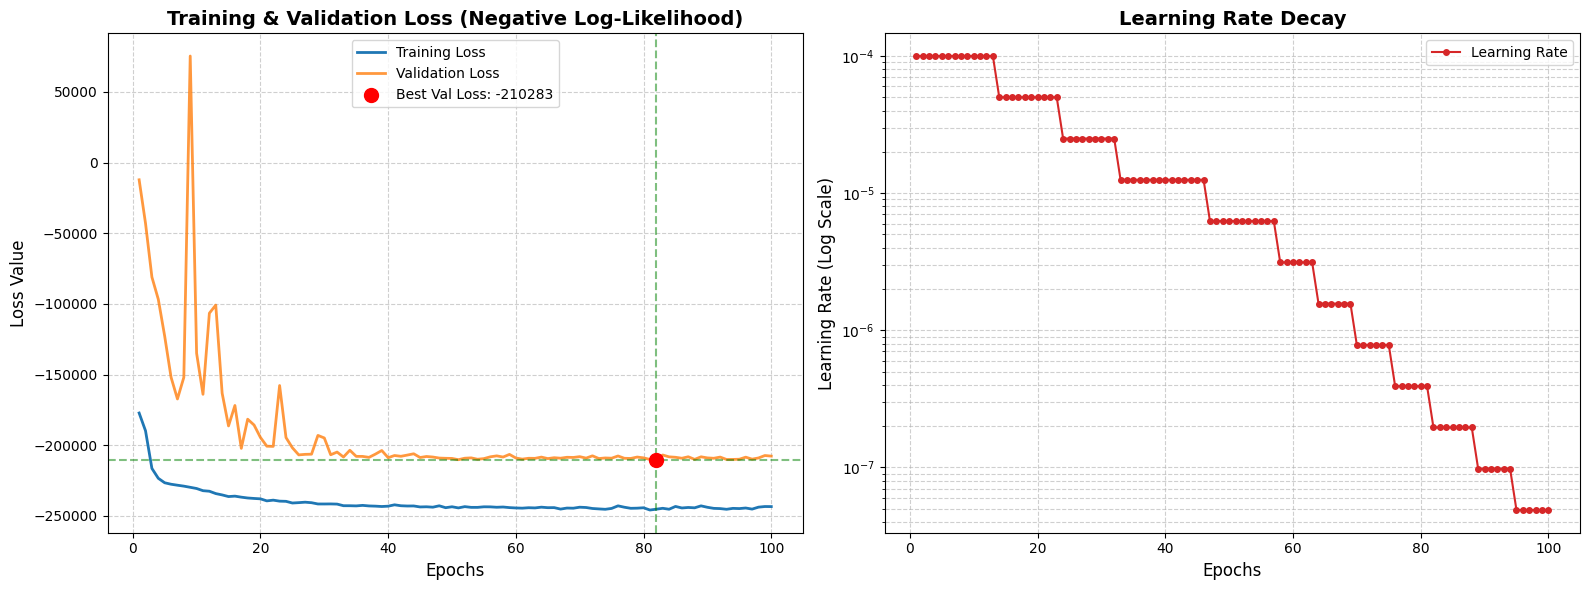

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_metrics(history):
    """
    Plots the training and validation loss curves, and the learning rate schedule.

    Args:
        history (dict): Dictionary containing 'train_loss', 'val_loss', and 'lr'.
    """

    # Extract data from history dictionary
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    learning_rates = history['lr']

    # Create epoch range (1 to N)
    epochs = range(1, len(train_loss) + 1)

    # Create a figure with two subplots
    plt.figure(figsize=(16, 6))

    # ---------------------------------------------------------
    # Plot 1: Training and Validation Loss
    # ---------------------------------------------------------
    plt.subplot(1, 2, 1)

    # Plot curves
    plt.plot(epochs, train_loss, label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, alpha=0.8)

    # Highlight the best validation loss
    best_val_loss = min(val_loss)
    best_epoch = val_loss.index(best_val_loss) + 1

    plt.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5, label=f'Best Val Loss: {best_val_loss:.0f}')
    plt.axhline(y=best_val_loss, color='green', linestyle='--', alpha=0.5)
    plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)

    # Styling
    plt.title('Training & Validation Loss (Negative Log-Likelihood)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    # ---------------------------------------------------------
    # Plot 2: Learning Rate Schedule
    # ---------------------------------------------------------
    plt.subplot(1, 2, 2)

    # Plot LR curve
    plt.plot(epochs, learning_rates, label='Learning Rate', color='#d62728', marker='o', markersize=4)

    # Styling
    plt.title('Learning Rate Decay', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Learning Rate (Log Scale)', fontsize=12)
    plt.yscale('log')  # Logarithmic scale makes it easier to see decay steps
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6, which='both')

    # Show the final plot
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
# Check if history exists before plotting
if 'training_history' in locals():
    print(">>> Generating training plots...")
    plot_training_metrics(training_history)
else:
    print(">>> Error: 'training_history' variable not found. Please train the model first.")

## 7. Training Analysis

The training and validation Negative Log-Likelihood curves are used to monitor how well the model learns the distribution of normal images.

The validation curve is also used to identify the best model checkpoint during training.

The learning-rate curve shows how the `ReduceLROnPlateau` scheduler adjusts the learning rate when the validation loss stops improving.

Differences between training and validation loss can occur because the model contains Batch Normalization layers and the training and evaluation modes use different normalization statistics.


## 8. Sampling from the Flow

Since a normalizing flow is invertible, it can also be used in the reverse direction to generate samples.

A latent vector is first sampled from the standard Gaussian distribution:

$$
u\sim\mathcal{N}(0,I)
$$

The flow transformations are then inverted to obtain an image:

$$
x=f^{-1}(u)
$$

However, sampling from an autoregressive flow requires sequential computation across the input dimensions. Since the input contains 49,152 dimensions, this process is computationally expensive and significantly slower than likelihood evaluation.

This difference is one of the important characteristics of MAF: it is particularly suitable when the main task is evaluating the likelihood of observed data.


>>> Generating 5 samples on cuda...


Inverting Blocks: 100%|██████████| 7/7 [12:44<00:00, 109.15s/it, Pixel 48000/49152]



>>> Plotting results...


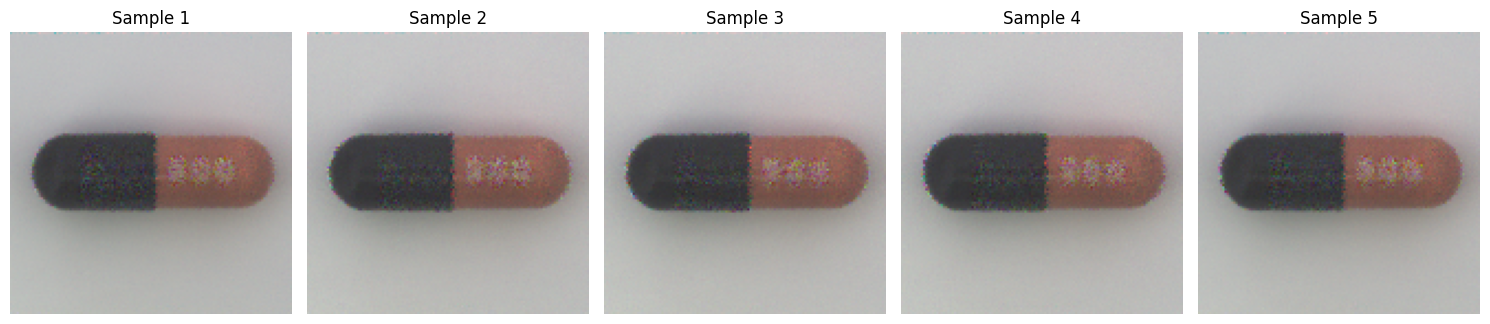

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # For progress bar

def generate_and_plot(model, num_samples=8, device='cuda'):
    """
    Generates new samples from the trained PixelMAF model and plots them.

    Args:
        model (nn.Module): The trained model.
        num_samples (int): Number of images to generate (Batch size).
        device (str): 'cuda' or 'cpu'.
    """
    print(f">>> Generating {num_samples} samples on {device}...")
    print("Warning: This is an autoregressive process and will take time!")

    model.eval()
    model.to(device)

    # -------------------------------------------------
    # Optimized Sampling Loop with Progress Bar
    # -------------------------------------------------
    with torch.no_grad():
        # Initialize random noise (z)
        u = torch.randn(num_samples, model.input_dim, device=device)

        # We need to manually control the loop to show progress
        # This mirrors the logic inside model.sample() but brings it out for tqdm
        iterator = tqdm(reversed(range(len(model.blocks))),
                       desc="Inverting Blocks",
                       total=len(model.blocks))

        for i in iterator:
            u = u.flip(dims=(1,))
            block = model.blocks[i]
            bn_module = model.batch_norms[i]

            # 1. Inverse BatchNorm
            x_hat = torch.zeros_like(u)
            bn = bn_module.bn
            gamma = bn.weight.view(1, -1)
            beta = bn.bias.view(1, -1)

            if bn.training:
                var = x_hat.var(dim=0, unbiased=False) + bn.eps
                mean = x_hat.mean(dim=0)
            else:
                var = bn.running_var + bn.eps
                mean = bn.running_mean

            x_hat = (u - beta) * torch.sqrt(var.view(1, -1)) / (gamma + 1e-12) + mean.view(1, -1)

            # 2. Inverse Autoregressive (The Slow Part)
            # We must iterate through every single dimension (pixel channel)
            u_recon = torch.zeros_like(x_hat)

            # Using a secondary progress bar for pixels could be too noisy,
            # so we just update description
            total_pixels = model.input_dim

            for j in range(total_pixels):
                # Update progress every 1000 pixels to avoid slowing down with prints
                if j % 2000 == 0:
                    iterator.set_postfix_str(f"Pixel {j}/{total_pixels}")

                mu, alpha = block(u_recon)
                u_recon[:, j] = x_hat[:, j] * torch.exp(alpha[:, j]) + mu[:, j]

            u = u_recon

        # Reshape to Image format (Batch, Channels, Height, Width)
        input_size = int(np.sqrt(model.input_dim // 3))
        generated_images = u.view(num_samples, 3, input_size, input_size)

    # -------------------------------------------------
    # Visualization
    # -------------------------------------------------
    print("\n>>> Plotting results...")

    # Move to CPU and normalize for plotting if necessary
    # Since inputs were standard tensors, they might be in any range.
    # Usually for visualization we clamp to [0, 1] or normalize.
    images_np = generated_images.cpu().numpy()

    # Simple Min-Max scaling to make images visible
    images_np = (images_np - images_np.min()) / (images_np.max() - images_np.min())

    # Create grid
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1: axes = [axes] # Handle single image case

    for idx, ax in enumerate(axes):
        # Transpose from (C, H, W) to (H, W, C) for Matplotlib
        img = np.transpose(images_np[idx], (1, 2, 0))

        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Sample {idx+1}")

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
# Assuming 'best_model' is already loaded in memory
if 'best_model' in locals():
    # Generate 5 images (Batching is more efficient on GPU)
    generate_and_plot(best_model, num_samples=5, device='cuda')
else:
    print("Error: Model not found. Please load or train the model first.")

## 9. Anomaly Detection

After training, the flow model is used to compute the likelihood of every test image.

The test set contains:

* `good` images, treated as normal samples
* Images from defect categories, treated as anomalous samples

For each image, the model computes:

$$
\log p(x)
$$

which is then converted into an anomaly score using:

$$
\text{Anomaly Score}(x)=-\log p(x)
$$

Therefore:

* **Low NLL:** the image is more consistent with the learned normal distribution.
* **High NLL:** the image is less likely under the learned normal distribution and is therefore considered more anomalous.

The model is never trained directly on the defective test images. The defect labels are used only during evaluation to measure how well the likelihood-based anomaly score separates normal and anomalous samples.



>>> Starting Anomaly Detection Evaluation...
Computing Likelihoods on Test Set...

Anomaly Detection Results (capsule)
AUROC Score: 75.23%
AUPR Score : 92.99%


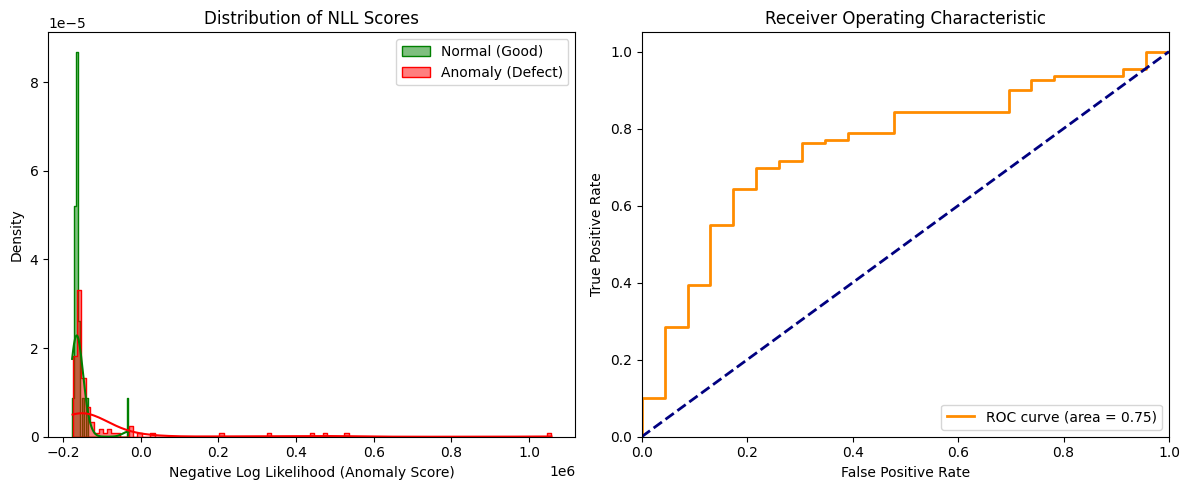

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

def evaluate_anomaly_detection(model, config):
    print("\n>>> Starting Anomaly Detection Evaluation...")

    # 1. Setup Test Pipeline
    # MVTec structure: 'test' folder contains 'good' (normal) and defect subfolders (anomalies)
    test_dir = os.path.join(config['dataset_path'], config['category'], 'test')

    transform = transforms.Compose([
        transforms.Resize((config['input_size'], config['input_size'])),
        transforms.ToTensor(),
    ])

    # ImageFolder automatically assigns classes based on subfolder names
    test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

    # Identify the index for the 'good' class
    if 'good' in test_dataset.class_to_idx:
        normal_class_idx = test_dataset.class_to_idx['good']
    else:
        raise ValueError("'good' folder not found in test dataset structure!")

    test_loader = DataLoader(
        test_dataset, batch_size=config['batch_size'], shuffle=False,
        num_workers=config['num_workers']
    )

    model.eval()

    y_true_labels = []
    y_scores_nll = []

    # 2. Inference Loop
    print("Computing Likelihoods on Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(config['device'])

            # Compute Log Probability using the Flow model
            # Output shape: (batch_size,)
            log_probs = model.log_prob(images)

            # Convert to Negative Log Likelihood (NLL) to use as Anomaly Score
            # Higher NLL indicates lower probability (higher anomaly score)
            nll_scores = -log_probs.cpu().numpy()

            # Binarize labels:
            # 0: Normal (Good class)
            # 1: Anomaly (All other classes)
            binary_labels = [0 if l == normal_class_idx else 1 for l in labels]

            y_true_labels.extend(binary_labels)
            y_scores_nll.extend(nll_scores)

    y_true_labels = np.array(y_true_labels)
    y_scores_nll = np.array(y_scores_nll)

    # 3. Calculate Metrics
    # AUROC (Area Under Receiver Operating Characteristic)
    auroc = roc_auc_score(y_true_labels, y_scores_nll)

    # AUPR (Area Under Precision-Recall Curve)
    precision, recall, _ = precision_recall_curve(y_true_labels, y_scores_nll)
    aupr = auc(recall, precision)

    print(f"\n========================================")
    print(f"Anomaly Detection Results ({config['category']})")
    print(f"========================================")
    print(f"AUROC Score: {auroc * 100:.2f}%")
    print(f"AUPR Score : {aupr * 100:.2f}%")

    # 4. Visualization
    plot_results(y_true_labels, y_scores_nll, auroc)

def plot_results(labels, scores, auroc_score):
    plt.figure(figsize=(12, 5))

    # Plot 1: Histogram of Score Distributions
    plt.subplot(1, 2, 1)
    sns.histplot(scores[labels==0], color='green', label='Normal (Good)', kde=True, stat="density", element="step")
    sns.histplot(scores[labels==1], color='red', label='Anomaly (Defect)', kde=True, stat="density", element="step")
    plt.title('Distribution of NLL Scores')
    plt.xlabel('Negative Log Likelihood (Anomaly Score)')
    plt.legend()

    # Plot 2: ROC Curve
    plt.subplot(1, 2, 2)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auroc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Ensure 'best_model' exists from the training phase
    if 'best_model' in globals():
        evaluate_anomaly_detection(best_model, CONFIG)
    else:
        print("Error: Trained model not found. Please run 'train_model' first.")

## 10. Evaluation Metrics

Because anomaly detection datasets are typically highly imbalanced, accuracy can be misleading. A model that predicts most samples as normal may achieve high accuracy while failing to detect anomalies.

The model is therefore evaluated using **AUROC** and **AUPR**.

### AUROC

The Area Under the Receiver Operating Characteristic curve measures how well the anomaly score separates normal and anomalous samples across different decision thresholds.

### AUPR

The Area Under the Precision-Recall curve focuses on the precision and recall of anomaly detection and is particularly informative when the classes are imbalanced.

For this experiment, `good` images are assigned the normal label, while all defect categories are treated as anomalies.


## 11. Results

The trained MAF model achieves the following results on the **MVTec AD capsule** test set:

| Metric |      Score |
| ------ | ---------: |
| AUROC  | **75.23%** |
| AUPR   | **92.99%** |

The NLL distribution shows that many normal images receive relatively concentrated scores, while a portion of the anomalous samples receives higher NLL values.

At the same time, there is noticeable overlap between the score distributions of normal and anomalous images. This indicates that although the learned likelihood provides useful information for anomaly detection, it does not completely separate all defective samples from the normal distribution.

The ROC curve and the score distributions provide a complementary view of the model's anomaly detection behavior.
